# Prior distribution and REgularization

This notebook demonstrates how a prior distribution changes parameter estimation in a simple case.

We use a two-parameter linear model:

`y = θ₀ + θ₁ x + ε`

where:

- `θ₀` is the intercept
- `θ₁` is the slope
- `ε` is  noise

We consider an L2 prior centered at `(0, 0)`:

`p(θ) = Normal(θ | 0, σ_prior² I)`



## Intuition

With only a few training points, outliers can pull the maximum likelihood estimate away from the trend that generated most of the data. A zero-centered Gaussian prior prefers smaller parameter values. If the data-only optimum has parameters that are too large in magnitude, this shrinkage can move the solution closer to the underlying signal and improve generalization.

Important distinction:

- The prior mean is `(0, 0)`.
- The true parameters are **not** `(0, 0)`.
- The prior still helps because it regularizes an overfit data-only solution.

In [92]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## Generate data

The true parameters are deliberately not zero:

`θ_true = (0.4, 1.0)`

The training data contain one high-leverage outlier. This makes the data-only maximum likelihood estimate too steep and too large in magnitude. A zero-mean prior can reduce this overfitting.

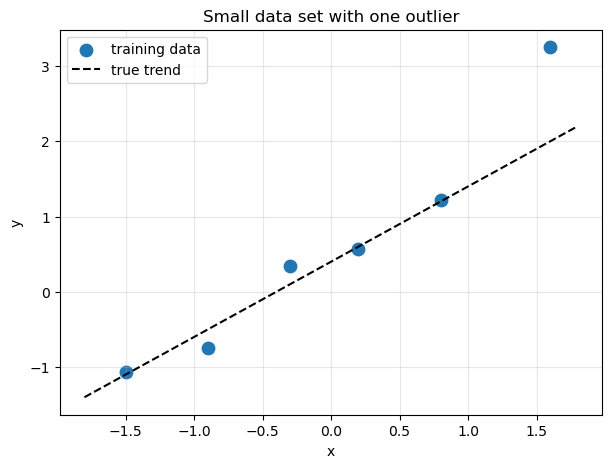

In [93]:
# True data-generating parameters, not equal to the prior mean
true_theta = np.array([0.4, 1.0])

# Training data: small sample with one high-leverage outlier
x_train = np.array([-1.5, -0.9, -0.3, 0.2, 0.8, 1.6])
y_clean_train = true_theta[0] + true_theta[1] * x_train

# Mostly small noise, plus one deliberately strong outlier at high x
noise = np.array([0.03, -0.25, 0.24, -0.03, 0.02, 1.25])
y_train = y_clean_train + noise

# Clean test data for checking generalization against the true trend
x_test = np.linspace(-1.8, 1.8, 200)
y_test_clean = true_theta[0] + true_theta[1] * x_test

plt.figure(figsize=(7, 5))
plt.scatter(x_train, y_train, s=80, label="training data", color="tab:blue")
plt.plot(x_test, y_test_clean, "k--", label="true trend")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Small data set with one outlier")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Define likelihood, zero-mean prior, and posterior

We assume Gaussian observation noise with known standard deviation `σ_noise`. The likelihood is:

`p(y | X, θ) ∝ exp(−SSE(θ) / (2 σ_noise²))`

The zero-mean Gaussian prior is:

`p(θ) ∝ exp(−λ ||θ||² / 2)`

The posterior is proportional to:

`p(θ | X, y) ∝ p(y | X, θ) p(θ)`

Equivalently, the MAP estimate minimizes:

`SSE(θ) / (2 σ_noise²) + λ ||θ||² / 2`

In [94]:
# Noise scale used in the likelihood
sigma_noise = 0.8

# L2 strength. Larger values create stronger shrinkage toward the zero prior mean.
lambda_l2 = 2.0

# Parameter grid for visualizing the objective landscape
theta0_grid = np.linspace(-0.6, 1.6, 300)
theta1_grid = np.linspace(-0.1, 2.3, 300)
T0, T1 = np.meshgrid(theta0_grid, theta1_grid)

def sse_on_grid(T0, T1, x, y):
    # Sum of squared errors for every point on the parameter grid
    residuals = y[:, None, None] - (T0[None, :, :] + T1[None, :, :] * x[:, None, None])
    return np.sum(residuals**2, axis=0)

SSE = sse_on_grid(T0, T1, x_train, y_train)
neg_log_likelihood = SSE / (2 * sigma_noise**2)
neg_log_prior = lambda_l2 * (T0**2 + T1**2) / 2
neg_log_posterior = neg_log_likelihood + neg_log_prior

# Convert negative log quantities into relative densities for nicer heatmaps.
# Subtracting the minimum avoids numerical underflow and makes the maximum equal to 1.
likelihood = np.exp(-(neg_log_likelihood - np.min(neg_log_likelihood)))
prior = np.exp(-(neg_log_prior - np.min(neg_log_prior)))
posterior = np.exp(-(neg_log_posterior - np.min(neg_log_posterior)))

## Compute MLE and MAP estimates

The MLE uses only the data likelihood. The MAP estimate combines the data likelihood with the zero-mean prior.

In [95]:
# Design matrix for y = theta0 + theta1*x
X_train = np.column_stack([np.ones_like(x_train), x_train])

# Maximum likelihood / least squares estimate
mle_theta = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)

# MAP / ridge estimate for the objective:
# SSE/(2*sigma_noise^2) + lambda_l2/2 * ||theta||^2
# This is equivalent to solving: (X^T X + lambda_l2*sigma_noise^2*I) theta = X^T y
map_theta = np.linalg.solve(
    X_train.T @ X_train + lambda_l2 * sigma_noise**2 * np.eye(2),
    X_train.T @ y_train
)

print("Prior mean:       ", np.array([0.0, 0.0]))
print("True parameters:  ", true_theta)
print("MLE parameters:   ", mle_theta)
print("MAP parameters:   ", map_theta)
print()
print("Distance MLE to true:", np.linalg.norm(mle_theta - true_theta))
print("Distance MAP to true:", np.linalg.norm(map_theta - true_theta))

Prior mean:        [0. 0.]
True parameters:   [0.4 1. ]
MLE parameters:    [0.616 1.335]
MAP parameters:    [0.504 1.111]

Distance MLE to true: 0.39822792752602737
Distance MAP to true: 0.15201151885941158


## Data likelihood only

This plot shows where the training data alone prefer the parameters to be. Because of the outlier, the maximum likelihood region is shifted toward larger intercept and slope values.

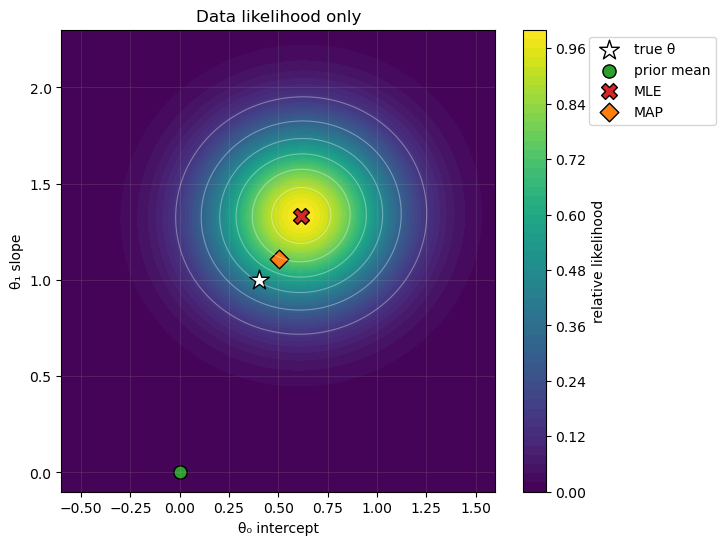

In [96]:
def plot_heatmap(Z, title, ax, cmap="viridis"):
    im = ax.contourf(T0, T1, Z, levels=60, cmap=cmap)
    ax.contour(T0, T1, Z, levels=8, colors="white", alpha=0.35, linewidths=0.8)
    ax.scatter(*true_theta, marker="*", s=220, color="white", edgecolor="black", label="true θ")
    ax.scatter(0, 0, marker="o", s=90, color="tab:green", edgecolor="black", label="prior mean")
    ax.scatter(*mle_theta, marker="X", s=130, color="tab:red", edgecolor="black", label="MLE")
    ax.scatter(*map_theta, marker="D", s=90, color="tab:orange", edgecolor="black", label="MAP")
    ax.set_xlabel("θ₀ intercept")
    ax.set_ylabel("θ₁ slope")
    ax.set_title(title)
    ax.grid(alpha=0.15)
    return im

fig, ax = plt.subplots(figsize=(7, 6))
im = plot_heatmap(likelihood, "Data likelihood only", ax)
fig.colorbar(im, ax=ax, label="relative likelihood")
ax.legend(loc="upper left", bbox_to_anchor=(1.2, 1.0))
plt.show()

## Prior likelihood only

The prior is centered at `(0, 0)`, not at the true parameters. It assigns highest density to small parameter values and gradually penalizes larger magnitudes.

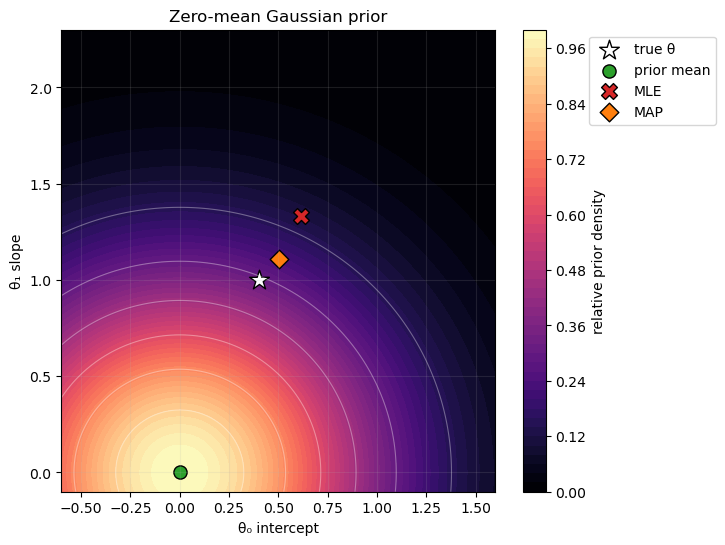

In [97]:
fig, ax = plt.subplots(figsize=(7, 6))
im = plot_heatmap(prior, "Zero-mean Gaussian prior", ax, cmap="magma")
fig.colorbar(im, ax=ax, label="relative prior density")
ax.legend(loc="upper left", bbox_to_anchor=(1.2, 1.0))
plt.show()

## Data Likelihood × Prior = Posterior

The posterior balances the data likelihood with the zero-mean prior. In this example, the prior pulls the overfit MLE back toward smaller parameter values. Even though `(0, 0)` is not the true parameter, this shrinkage improves the estimate.

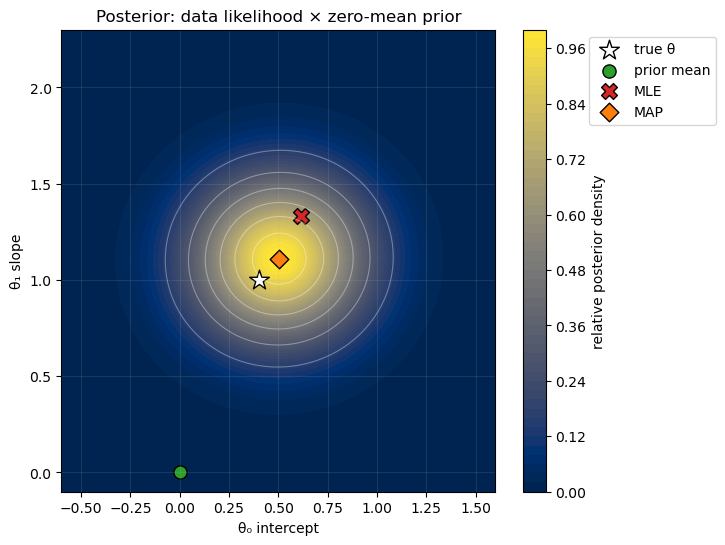

In [98]:
fig, ax = plt.subplots(figsize=(7, 6))
im = plot_heatmap(posterior, "Posterior: data likelihood × zero-mean prior", ax, cmap="cividis")
fig.colorbar(im, ax=ax, label="relative posterior density")
ax.legend(loc="upper left", bbox_to_anchor=(1.2, 1.0))
plt.show()

## Side-by-side comparison

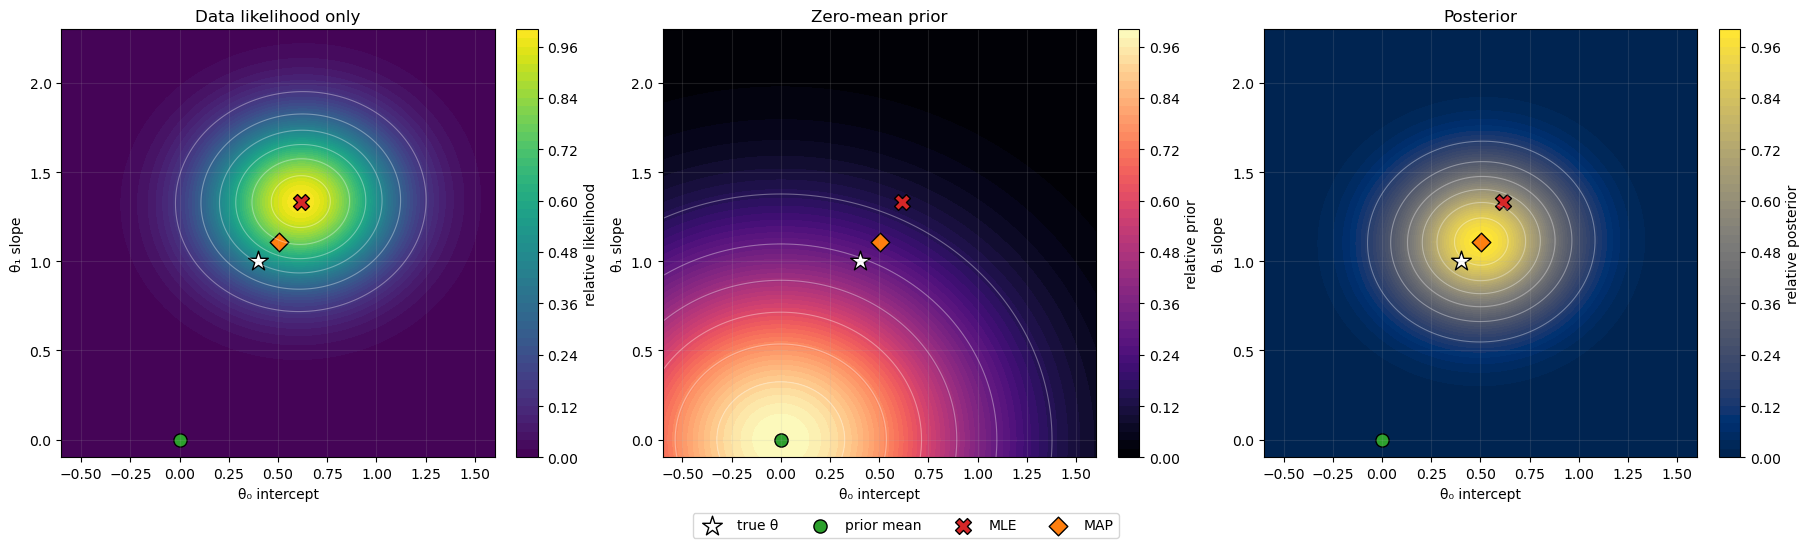

In [99]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

plots = [
    (likelihood, "Data likelihood only", "viridis", "relative likelihood"),
    (prior, "Zero-mean prior", "magma", "relative prior"),
    (posterior, "Posterior", "cividis", "relative posterior"),
]

for ax, (Z, title, cmap, cbar_label) in zip(axes, plots):
    im = plot_heatmap(Z, title, ax, cmap=cmap)
    fig.colorbar(im, ax=ax, label=cbar_label)

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.08))
plt.show()

## Compare fitted lines and test error

The test set follows the clean true trend, without the outlier. This lets us check whether the prior improves generalization.

Test MSE of MLE: 0.1688
Test MSE of MAP with zero-mean prior: 0.0242
Relative improvement: 85.6%


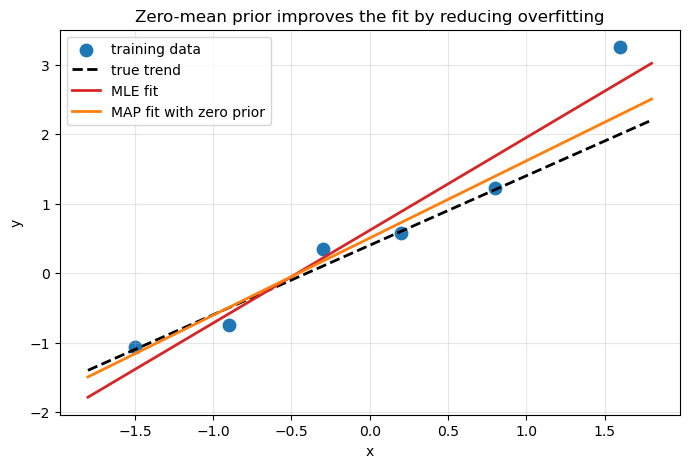

In [100]:
def predict(theta, x):
    return theta[0] + theta[1] * x

mle_pred_test = predict(mle_theta, x_test)
map_pred_test = predict(map_theta, x_test)

mle_mse = np.mean((mle_pred_test - y_test_clean)**2)
map_mse = np.mean((map_pred_test - y_test_clean)**2)

print(f"Test MSE of MLE: {mle_mse:.4f}")
print(f"Test MSE of MAP with zero-mean prior: {map_mse:.4f}")
print(f"Relative improvement: {(mle_mse - map_mse) / mle_mse * 100:.1f}%")

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, s=80, label="training data", color="tab:blue")
plt.plot(x_test, y_test_clean, "k--", linewidth=2, label="true trend")
plt.plot(x_test, mle_pred_test, color="tab:red", linewidth=2, label="MLE fit")
plt.plot(x_test, map_pred_test, color="tab:orange", linewidth=2, label="MAP fit with zero prior")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Zero-mean prior improves the fit by reducing overfitting")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Play around!

Try changing `lambda_l2` above and re-running the notebook.

Try changing the data points.

Try changing the data likelihood assumption (assumption on noise level).

Typical behavior:

- `lambda_l2 = 0`: no prior influence, identical to MLE
- small to moderate `lambda_l2`: beneficial shrinkage
- very large `lambda_l2`: too much shrinkage toward `(0, 0)`, causing underfitting

So the zero-mean prior is helpful here not because it is perfectly correct, but because it counteracts overfitting from limited, noisy data.